In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
import pandas as pd

# Load dataset (IMPORTANT: file must be in same folder as notebook)
df = pd.read_csv("spotify_top_1000_tracks.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [7]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles inside folder:")
print(os.listdir())

Current folder:
c:\Users\ex012\Desktop\Activity7_DataVisualization

Files inside folder:
['.git', 'Activity7.ipynb', 'popularity_trend.gif', 'spotify_top_1000_tracks.csv']


In [8]:
# Convert release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year
df['year'] = df['release_date'].dt.year

# Remove missing values
df = df.dropna(subset=['year', 'popularity', 'duration_min'])

# Convert year to integer
df['year'] = df['year'].astype(int)

# Clean text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'])

print("Data cleaned successfully!")
df.head()

Data cleaned successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min,year
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767,2018
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883,2016
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667,2019
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083,2020
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433,2016


In [17]:
if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=[0, 100, 140, np.inf],
        labels=['Slow', 'Medium', 'Fast']
    )

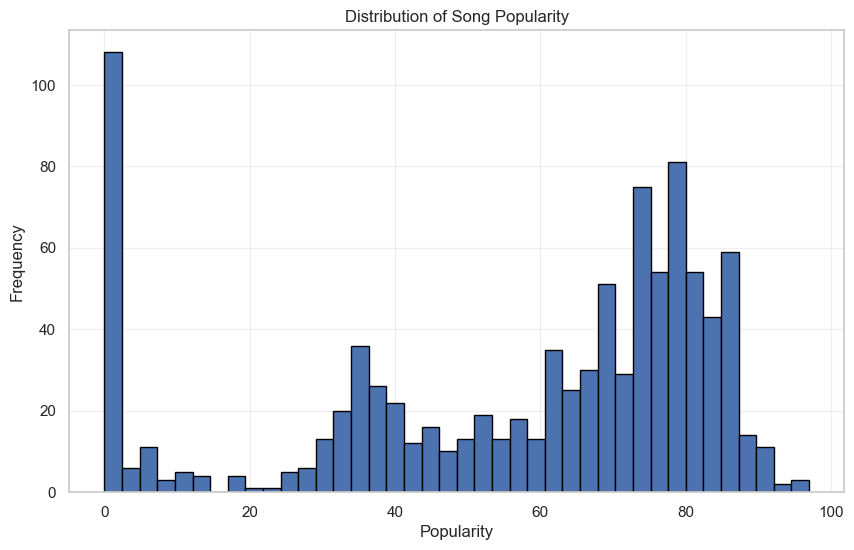

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df['popularity'], bins=40, edgecolor='black')

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

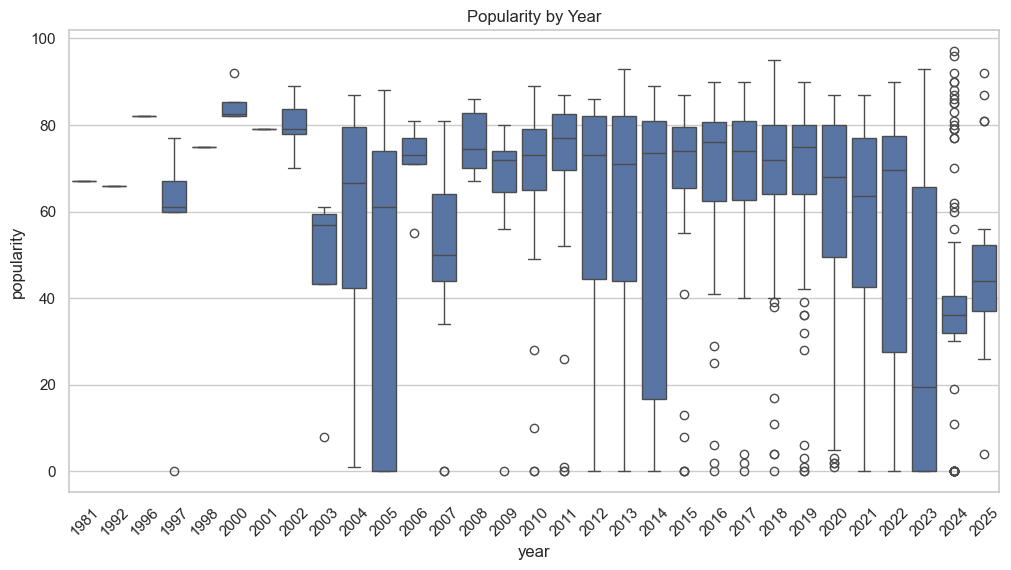

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(x='year', y='popularity', data=df)

plt.title("Popularity by Year")
plt.xticks(rotation=45)

plt.show()

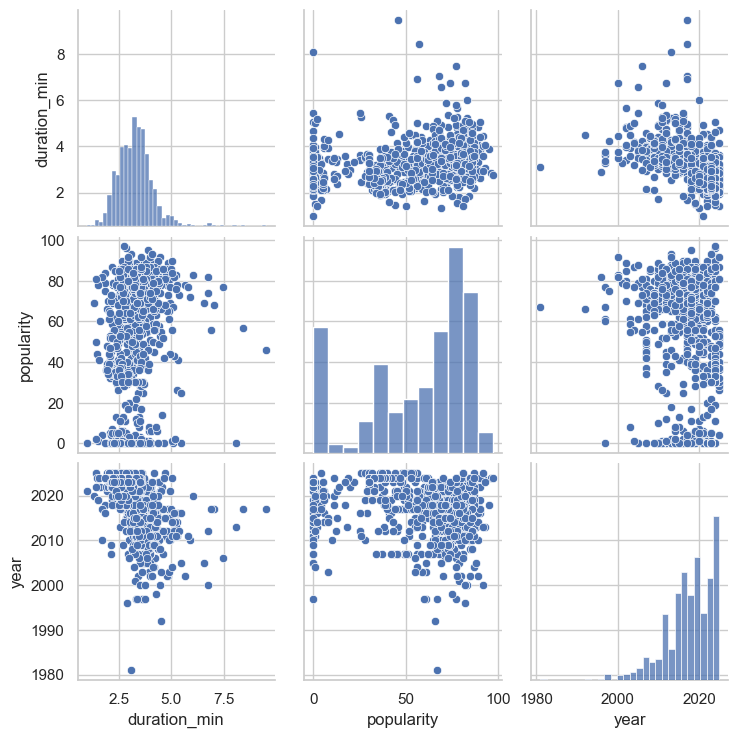

In [11]:
import seaborn as sns

sns.pairplot(df[['duration_min', 'popularity', 'year']].dropna())

plt.show()

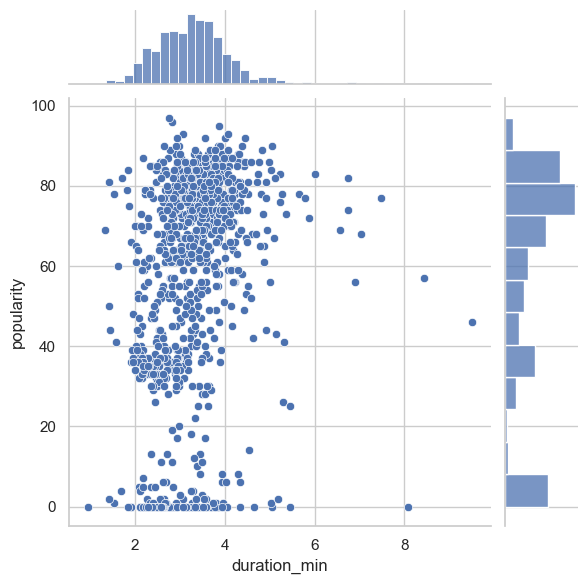

In [12]:
import seaborn as sns

sns.jointplot(x='duration_min', y='popularity', data=df, kind='scatter')

plt.show()

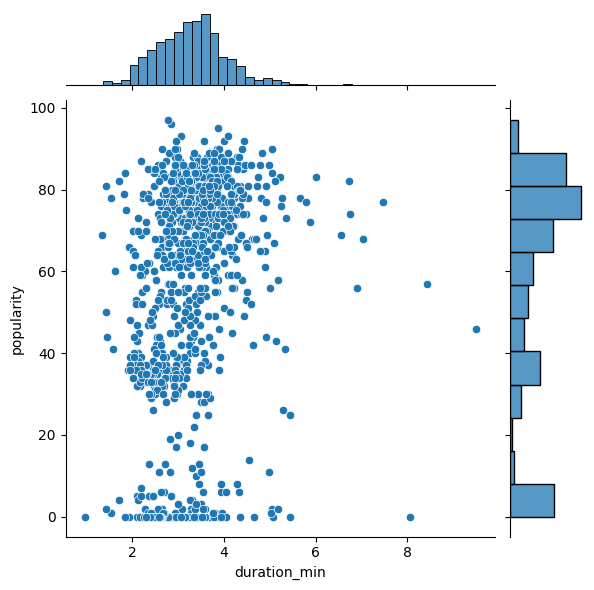

In [13]:
sns.jointplot(x='duration_min', y='popularity', data=df, kind='scatter')
plt.show()

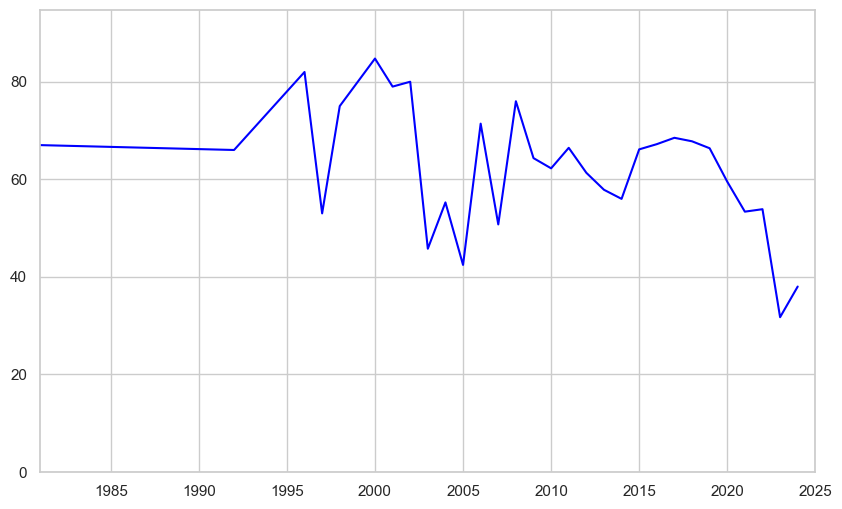

GIF saved successfully!


In [13]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Compute yearly average popularity
yearly = df.groupby('year')['popularity'].mean().reset_index()
yearly = yearly.sort_values('year')

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(yearly['year'].min(), yearly['year'].max())
ax.set_ylim(0, yearly['popularity'].max() + 10)

line, = ax.plot([], [], color='blue')

# Update function for animation
def update(i):
    x = yearly['year'][:i]
    y = yearly['popularity'][:i]
    line.set_data(x, y)
    return line,

# Create animation
ani = FuncAnimation(fig, update, frames=len(yearly), interval=100)

# Save GIF
ani.save("popularity_trend.gif", writer=PillowWriter(fps=10))

plt.show()

print("GIF saved successfully!")

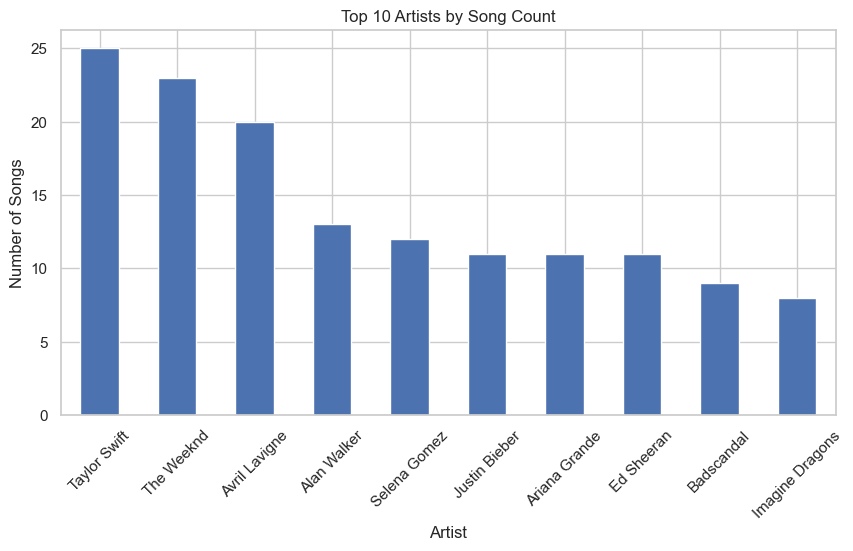

In [14]:
top_artists = df['artist'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_artists.plot(kind='bar')

plt.title("Top 10 Artists by Song Count")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)

plt.show()

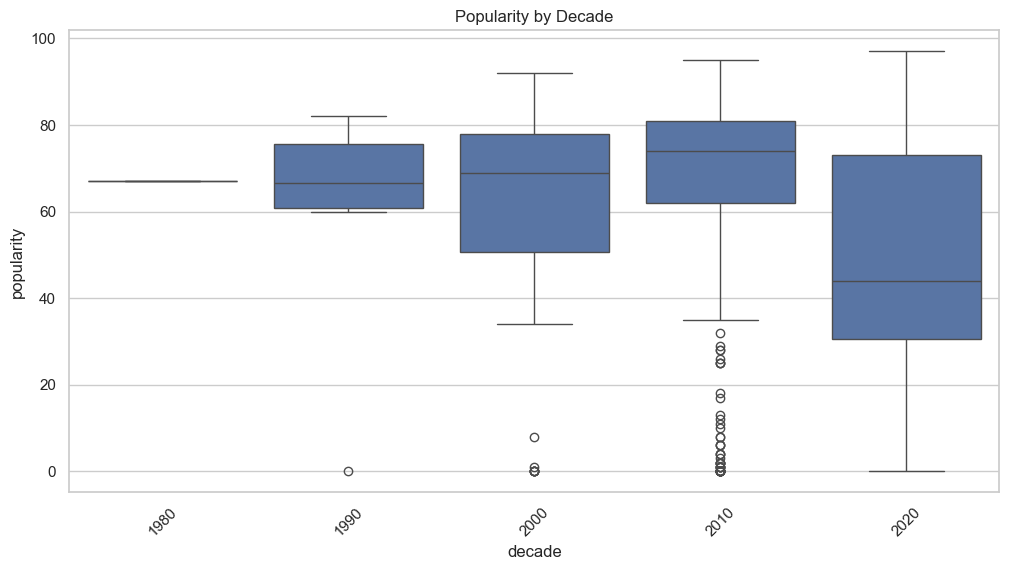

In [15]:
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='popularity', data=df)

plt.title("Popularity by Decade")
plt.xticks(rotation=45)

plt.show()

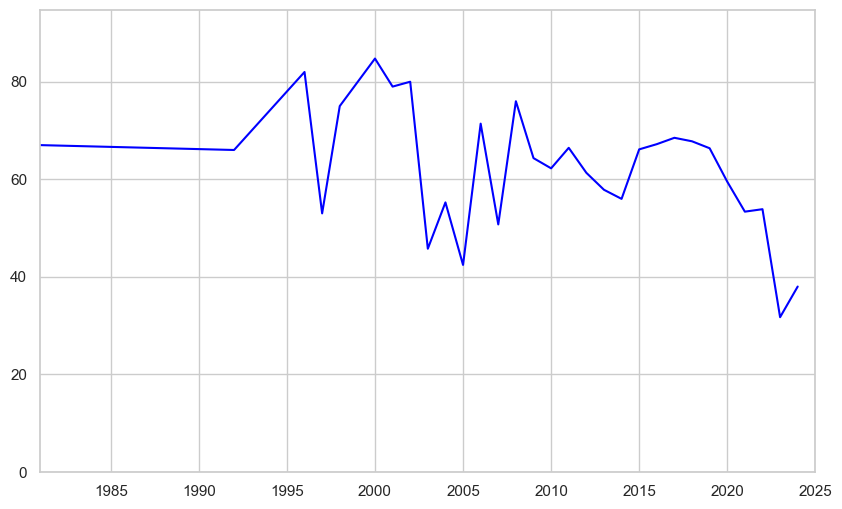

In [16]:
from matplotlib.animation import FuncAnimation, PillowWriter

yearly = df.groupby('year')['popularity'].mean().reset_index()
yearly = yearly.sort_values('year')

fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(yearly['year'].min(), yearly['year'].max())
ax.set_ylim(0, yearly['popularity'].max() + 10)

line, = ax.plot([], [], color='blue')

def update(i):
    x = yearly['year'][:i]
    y = yearly['popularity'][:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(yearly), interval=100)

ani.save("yearly_popularity_main.gif", writer=PillowWriter(fps=10))

plt.show()

In [17]:
ani.save("yearly_popularity_try_it.gif", writer=PillowWriter(fps=15))

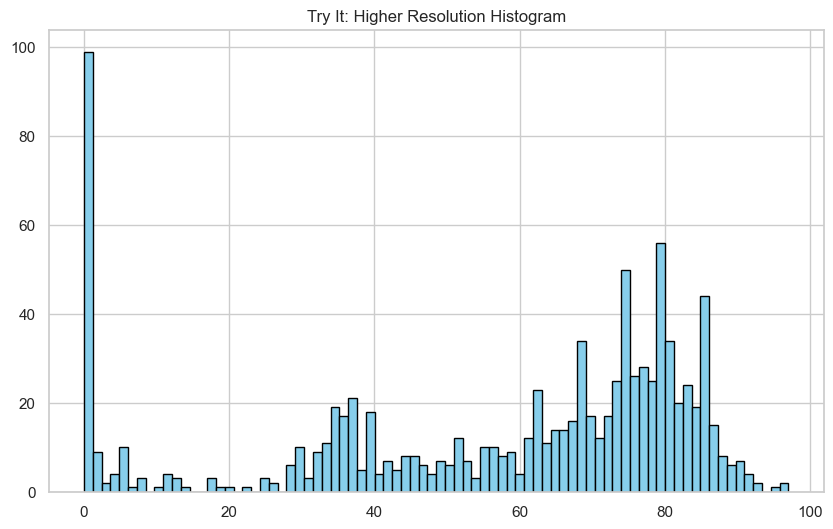

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df['popularity'], bins=80, edgecolor='black', color='skyblue')

plt.title("Try It: Higher Resolution Histogram")
plt.show()

C:\Users\ex012\AppData\Local\Temp\ipykernel_31752\2620223342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


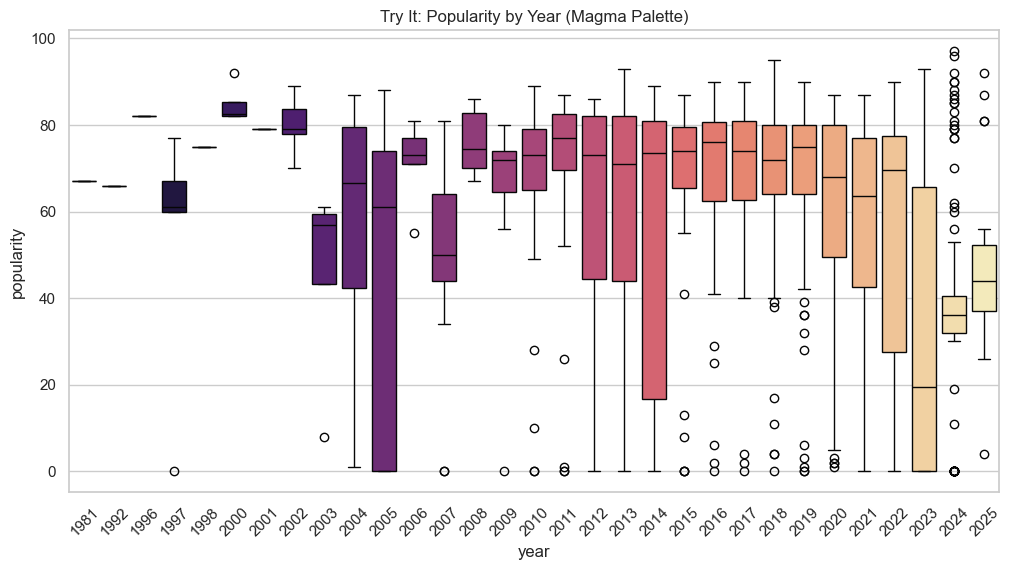

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='year', y='popularity', data=df, palette='magma')

plt.title("Try It: Popularity by Year (Magma Palette)")
plt.xticks(rotation=45)

plt.show()

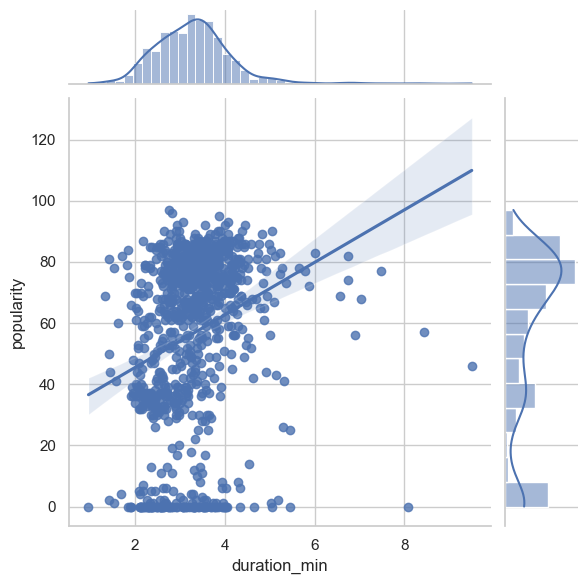

In [20]:
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg'
)

plt.show()

In [ ]:
sns.pairplot(df[['duration_min', 'popularity', 'year']].dropna(), diag_kind='kde')
plt.show()